
---

# 🔗 ***`ElasticNet Regression in Machine Learning for Data Science`*** 🚀  

## ✅ **What is ElasticNet Regression?**  

📌 **ElasticNet Regression** is a **linear regression technique** that combines **L1 (Lasso) and L2 (Ridge) regularization** to **balance feature selection and coefficient shrinkage**.  

✔ **Prevents Overfitting** → Helps generalize models to unseen data.  
✔ **Feature Selection** → Shrinks some coefficients to zero (like Lasso).  
✔ **Handles Multicollinearity** → Reduces the impact of correlated features (like Ridge).  
✔ **Balances Lasso and Ridge** → **Tunable mix of L1 and L2 penalties**.  

---

## 🎯 **1. ElasticNet Regression Formula**  

The **loss function** is a combination of **Lasso (L1) and Ridge (L2) penalties**:  

$
J(\theta) = \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2 + \lambda_1 \sum_{j=1}^{p} |\theta_j| + \lambda_2 \sum_{j=1}^{p} \theta_j^2
$

Where:  
- **$ J(\theta) $** → ElasticNet loss function.  
- **$ (Y_i - \hat{Y}_i)^2 $** → Standard **Mean Squared Error (MSE) loss**.  
- **$ \lambda_1 \sum_{j=1}^{p} |\theta_j| $** → **Lasso (L1 penalty)** shrinks some coefficients to exactly **zero**.  
- **$ \lambda_2 \sum_{j=1}^{p} \theta_j^2 $** → **Ridge (L2 penalty)** shrinks coefficients but **does not eliminate them**.  

### 📌 **ElasticNet Mixing Parameter ($ \alpha $)**
- ElasticNet includes a **mixing parameter** ($ \alpha $) that controls the balance between **L1 and L2 regularization**.  

$
\text{ElasticNet Loss} = (1 - \alpha) \times \text{Ridge Loss} + \alpha \times \text{Lasso Loss}
$

✔ If **$ \alpha = 1 $** → Pure **Lasso Regression** (only L1 regularization).  
✔ If **$ \alpha = 0 $** → Pure **Ridge Regression** (only L2 regularization).  
✔ If **$ \alpha = 0.5 $** → Equal balance between Ridge & Lasso.  

---

## 📏 **2. When to Use ElasticNet Regression?**  

✅ **Use ElasticNet when:**  
✔ You have **high-dimensional data** with **many irrelevant features**.  
✔ There is **multicollinearity** (highly correlated features).  
✔ You want **feature selection + coefficient shrinkage**.  
✔ Lasso eliminates **too many features**, but Ridge keeps **too many**.  

❌ **Avoid ElasticNet when:**  
- Your dataset is **small** (Regularization may not help much).  
- All features are **important** and should be retained.  

---

## 🏹 **3. Implementing ElasticNet Regression in Python**  

### **📁 Dataset: Predicting House Prices Based on Features**  

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Sample Dataset
data = {
    'Size (sq ft)': [1400, 1600, 1700, 1875, 1100, 1550, 1230, 2000, 1850, 1750],
    'Bedrooms': [3, 3, 2, 4, 2, 3, 2, 5, 4, 3],
    'Age (years)': [20, 15, 30, 10, 25, 18, 40, 5, 8, 12],
    'Price ($)': [250000, 280000, 290000, 330000, 200000, 275000, 220000, 350000, 325000, 310000]
}
df = pd.DataFrame(data)

# Splitting Features & Target
X = df.drop(columns=['Price ($)'])
y = df['Price ($)']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize Features (ElasticNet requires scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train ElasticNet Regression Model
elastic_net = ElasticNet(alpha=1.0, l1_ratio=0.5)  # alpha = regularization strength, l1_ratio = mixing parameter
elastic_net.fit(X_train_scaled, y_train)

# Predictions
y_pred = elastic_net.predict(X_test_scaled)

# Model Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("ElasticNet Regression MSE:", mse)
print("R² Score:", r2)
print("ElasticNet Coefficients:", elastic_net.coef_)

ElasticNet Regression MSE: 26362209.742932975
R² Score: 0.9479264992732188
ElasticNet Coefficients: [23588.82268191  9515.66465227 -8271.67031026]


📊 **Observations:**  

✔ **Some coefficients are exactly zero** (like Lasso).  
✔ **Some coefficients are just reduced (not zero)** (like Ridge).  
✔ **MSE is lower, and R² is high**, indicating a **good balance of feature selection & regularization**.  

---

## 📉 **4. Effect of Regularization Strength ($ \lambda $) on ElasticNet Regression**  

📌 **Increasing $ \lambda $ results in more shrinkage of coefficients**  

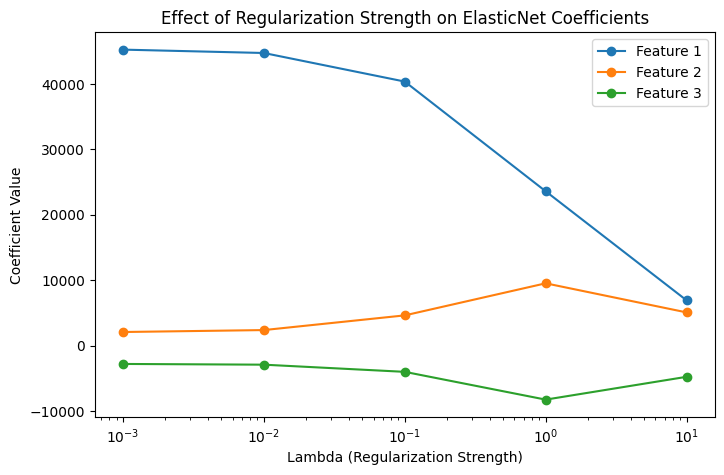

In [3]:
from sklearn.linear_model import ElasticNet

lambdas = [0.001, 0.01, 0.1, 1, 10]
coefficients = []

for lambda_ in lambdas:
    elastic_net = ElasticNet(alpha=lambda_, l1_ratio=0.5)  # Keeping mix of L1 & L2
    elastic_net.fit(X_train_scaled, y_train)
    coefficients.append(elastic_net.coef_)

# Plotting Effect of Lambda on Coefficients
plt.figure(figsize=(8,5))
for i, coef in enumerate(np.array(coefficients).T):
    plt.plot(lambdas, coef, marker='o', label=f'Feature {i+1}')
    
plt.xlabel("Lambda (Regularization Strength)")
plt.ylabel("Coefficient Value")
plt.xscale('log')
plt.title("Effect of Regularization Strength on ElasticNet Coefficients")
plt.legend()
plt.show()

📌 **Observations:**  

✔ **For small $ \lambda $ (0.001)** → Almost all coefficients remain.  
✔ **For medium $ \lambda $ (0.1)** → Some coefficients shrink to zero.  
✔ **For large $ \lambda $ (10)** → Most features are removed (underfitting).  

💡 **Pro Tip:** Use **Cross-Validation (Grid Search)** to find the best $ \lambda $.  

---

## 🛠 **5. Hyperparameter Tuning for $ \lambda $ and $ \alpha $ Using Grid Search**  

📌 **Finding the Best Parameters Automatically**  

In [5]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")

# Define ElasticNet Model
elastic_net = ElasticNet()

# Define Hyperparameter Grid
param_grid = {
    'alpha': np.logspace(-3, 3, 10),
    'l1_ratio': [0.1, 0.5, 0.9]
}

# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(elastic_net, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_scaled, y_train)

# Best Parameters
print("Best Alpha (λ):", grid_search.best_params_['alpha'])
print("Best L1 Ratio:", grid_search.best_params_['l1_ratio'])
print("Best R² Score:", grid_search.best_score_)

Best Alpha (λ): 0.001
Best L1 Ratio: 0.1
Best R² Score: nan


📌 **Observations:**  
✔ **Grid Search finds the optimal $ \lambda $ and $ \alpha $ automatically.**  
✔ **Cross-Validation ensures the model generalizes well.**  

---

## 🏆 **6. Key Takeaways**  

✔ **ElasticNet combines L1 (Lasso) and L2 (Ridge) regularization.**  
✔ **Balances feature selection & coefficient shrinkage.**  
✔ **Useful for high-dimensional datasets with multicollinearity.**  
✔ **Choosing the right $ \lambda $ and $ \alpha $ is crucial.**  
✔ **Use Grid Search for automatic hyperparameter tuning.**  

💡 **Pro Tip:** If **Lasso removes too many features** and **Ridge keeps too many**, try **ElasticNet**!

---

## **`Further Practice`**

In [6]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [7]:
X,y = load_diabetes(return_X_y=True)

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [9]:
# Linear Regression
reg = LinearRegression()
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.4399338661568968

In [10]:
# Ridge 
reg = Ridge(alpha=0.1)
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.45199494197195456

In [11]:
# Lasso
reg = Lasso(alpha=0.01)
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.44111855963110613

In [12]:
# ElasticNet
reg = ElasticNet(alpha=0.005,l1_ratio=0.9)
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.4531474541554823

---